In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [10]:
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True
)

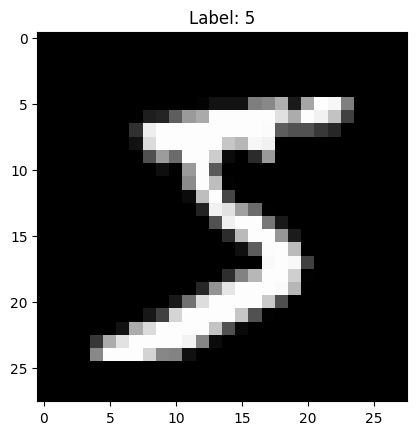

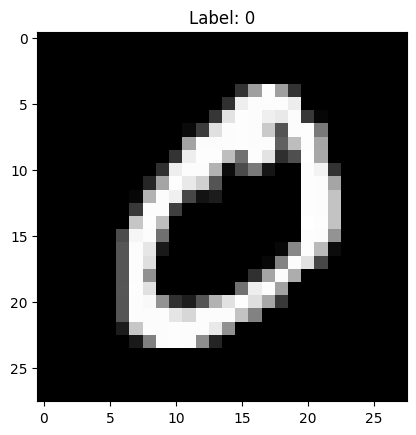

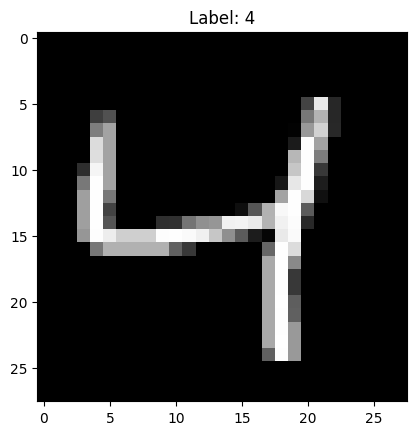

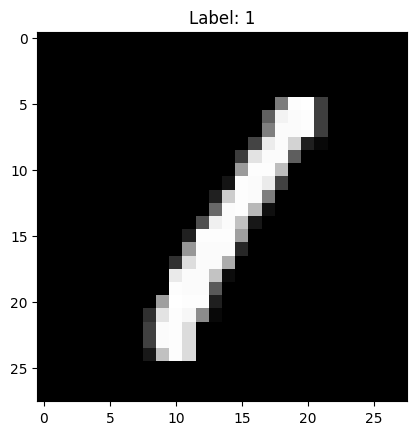

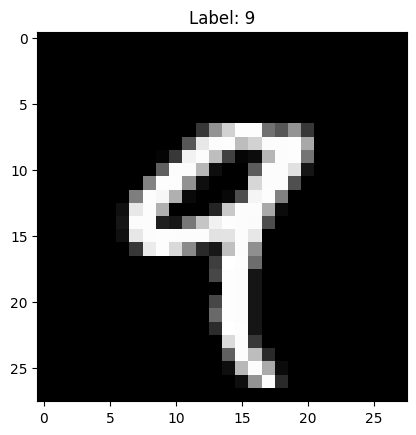

Shape of a sample image (PIL): (28, 28)


In [11]:

for i in range(5):
    img, label = train_dataset[i]
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {label}")
    plt.show()
print(f"Shape of a sample image (PIL): {train_dataset[0][0].size}")

In [17]:
stats_dataset = datasets.MNIST(
    root="data", train=True, download=True, transform=transforms.ToTensor()
)
stats_loader = DataLoader(stats_dataset, batch_size=1024, shuffle=False, num_workers=0)
total_sum = 0.0
total_sq = 0.0
n = 0
for images, _ in stats_loader:
    total_sum += images.sum().item()
    total_sq += (images ** 2).sum().item()
    n += images.numel()
mean = total_sum / n
std = (total_sq / n - mean ** 2) ** 0.5
mnist_mean = (mean,)
mnist_std = (std,)
print(f"Computed MNIST mean={mean:.4f}, std={std:.4f}")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std),
])
train_dataset = datasets.MNIST(
    root="data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="data", train=False, download=True, transform=transform
)
train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False, num_workers=0
)

Computed MNIST mean=0.1307, std=0.3081


In [18]:
images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")
print(f"Label dtype: {labels.dtype}, image dtype: {images.dtype}")
print(f"Image value range after normalize: [{images.min():.3f}, {images.max():.3f}]")


Batch images shape: torch.Size([64, 1, 28, 28])
Batch labels shape: torch.Size([64])
Label dtype: torch.int64, image dtype: torch.float32
Image value range after normalize: [-0.424, 2.822]


In [19]:
class MNISTNet(nn.Module):
    """Conv blocks reduce 28x28 spatial size; linear head maps features to 10 digits."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout_conv = nn.Dropout(0.25)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.log_softmax = nn.LogSoftmax(dim=1)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout_conv(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout_fc(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return self.log_softmax(x)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = MNISTNet().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Using device: cuda
MNISTNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout_conv): Dropout(p=0.25, inplace=False)
  (dropout_fc): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (log_softmax): LogSoftmax(dim=1)
)

Total parameters: 426,122
Trainable parameters: 426,122


In [20]:
def train(model,epoches,device):
        
        loss_list=[]
        model.train()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        scheduler=optim.lr_scheduler.StepLR(optimizer,step_size=10,gamma=0.1)
        criterion=nn.NLLLoss()
        for i in range(0,epoches):
                avg=0
                for images,labels in train_loader:
                        images=images.to(device)
                        labels=labels.to(device)
                        optimizer.zero_grad()
                        output=model(images)
                        loss=criterion(output,labels)
                        avg+=loss.item()
                        loss.backward()
                        optimizer.step()
                scheduler.step()
                avg/=len(train_loader)
                loss_list.append(avg)
                print(f"Loss for epoch {i+1} is {avg}")


        plt.figure(figsize=(8, 5))
        plt.plot(range(1, epoches + 1), loss_list, marker='o')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss vs Epoch")
        plt.grid(True)
        plt.show()

                        
    

Loss for epoch 1 is 0.21413445427950753
Loss for epoch 2 is 0.07550610897582033
Loss for epoch 3 is 0.05655731132421801
Loss for epoch 4 is 0.049960023373179736
Loss for epoch 5 is 0.042005975739203213
Loss for epoch 6 is 0.03752109734608339
Loss for epoch 7 is 0.031137039492954002
Loss for epoch 8 is 0.02949731475095573
Loss for epoch 9 is 0.025646779480763698
Loss for epoch 10 is 0.02452415182984635
Loss for epoch 11 is 0.014795325650155875
Loss for epoch 12 is 0.01113147636661141
Loss for epoch 13 is 0.01005153073620754
Loss for epoch 14 is 0.008840627728461656
Loss for epoch 15 is 0.008100780134095356
Loss for epoch 16 is 0.008220636343175991
Loss for epoch 17 is 0.007006312905124398
Loss for epoch 18 is 0.0060393294454138945
Loss for epoch 19 is 0.005965488198849443
Loss for epoch 20 is 0.00613642784567306
Loss for epoch 21 is 0.005282233798378512
Loss for epoch 22 is 0.00496820552619866
Loss for epoch 23 is 0.005505584742149186
Loss for epoch 24 is 0.0055435531757694586
Loss for 

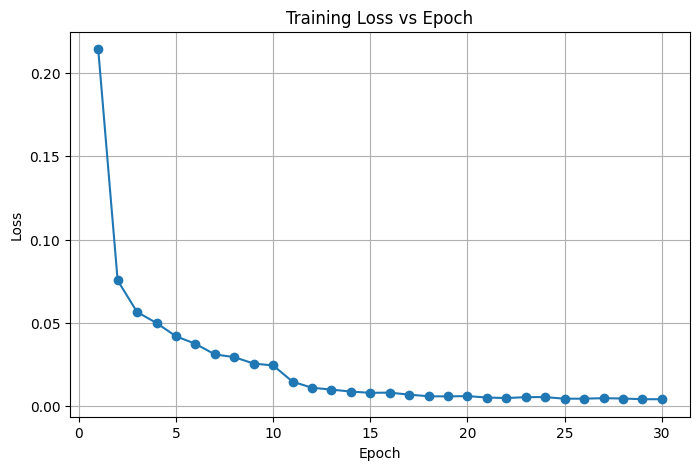

In [21]:
train(model,30,device)

In [25]:
def test(model,device):
    model.eval()
    correct=0
    total=0
    with torch.no_grad():
        for images,labels in test_loader:
            images=images.to(device)
            labels=labels.to(device)
            output=model(images)
            preds = output.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        accuracy=correct/total*100
        print(f"Accuracy : {accuracy}")

In [26]:
test(model,device)

Accuracy : 99.53999999999999


In [27]:
torch.save(model.state_dict(), "mnist_weights.pth")

In [28]:
model2 = MNISTNet() 

model2.load_state_dict(
    torch.load("mnist_weights.pth", map_location="cuda")
)


<All keys matched successfully>

In [ ]:
model2.eval()
with torch.no_grad():
    image, label = test_dataset[0]   
    image = image.unsqueeze(0)  
    image=image.to(device)
    output = model(image)
    pred = output.argmax(dim=1).item()

print("Prediction:", pred)
print("Actual:", label)

Prediction: 7
Actual: 7


The model gives an accuracy of 99.54 which is already pertty good to make it better we can add augmentation feature for the training images so the model
can learn more varieties of the training data.